In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -------------------- 1. KALMAN FILTER (For Dynamic Beta) --------------------
class KalmanRegressor:
    """
    Tracks the time-varying relationship: y = beta * x + alpha + noise
    State vector: [beta, alpha]
    """
    def __init__(self, delta=1e-4, R=50.0):
        self.delta = delta  # State transition noise (how fast beta drifts)
        self.R = R          # Measurement noise (observation error)
        
        # State Mean (Beta, Alpha) & Covariance Matrix
        self.x_hat = np.array([1.0, 0.0])  
        self.P = np.eye(2) * 1000.0  
        
    def update(self, x_t, y_t):
        """Update filter with new observation (x_t, y_t)"""
        # 1. Prediction Step (F = I, Q = delta * I)
        H = np.array([x_t, 1.0]).reshape(1, 2)  # Observation matrix
        Q = np.eye(2) * self.delta
        self.P = self.P + Q
        
        # 2. Update Step
        y_pred = H @ self.x_hat
        residual = y_t - y_pred
        S = H @ self.P @ H.T + self.R
        K = (self.P @ H.T) / S  # Kalman Gain
        
        self.x_hat = self.x_hat + K.flatten() * residual
        self.P = (np.eye(2) - K @ H) @ self.P
        
        return self.x_hat[0], self.x_hat[1], residual[0]

In [64]:
# ------------------- 2. FETCH REAL PAIRS DATA (WITH VOLUME) -------------------
import yfinance as yf

ticker_a = "BYND"
ticker_b = "QQQ"

print(f"📥 Downloading real data for {ticker_a} and {ticker_b}...")

# Download Close AND Volume
df_a = yf.download(ticker_a, start="2018-01-01", end="2024-01-01", progress=False)[['Close', 'Volume']]
df_b = yf.download(ticker_b, start="2018-01-01", end="2024-01-01", progress=False)[['Close', 'Volume']]

# Flatten MultiIndex columns and rename
df_a.columns = ['X', 'X_Volume']
df_b.columns = ['Y', 'Y_Volume']

# Concatenate and align
data = pd.concat([df_a, df_b], axis=1).dropna()

# Calculate combined volume (or use min(average_volume) for conservative impact)
data['Volume'] = np.minimum(data['X_Volume'], data['Y_Volume'])  # Use the less liquid asset

# Safety check
if data.empty:
    print("❌ ERROR: No data downloaded.")
    exit()

print(f"✅ Loaded {len(data)} daily bars from {data.index[0].date()} to {data.index[-1].date()}")

# Cointegration check (optional)
spread = data['X'] - data['Y']
from statsmodels.tsa.stattools import adfuller
adf_stat, p_value, _, _, _, _ = adfuller(spread)
print(f"🔬 ADF P-Value: {p_value:.4f} {'✅ Good!' if p_value < 0.05 else '⚠️ Consider a different pair.'}")

📥 Downloading real data for SPY and QQQ...
✅ Loaded 1509 daily bars from 2018-01-02 to 2023-12-29
🔬 ADF P-Value: 0.3090 ⚠️ Consider a different pair.


In [65]:
def run_backtest(data, lookback=60, entry_z=3.0, exit_z=0.5, cost_bps=10, delta=1e-6, R=50.0):
    """
    Complete backtest engine with Kalman Filter, dynamic market impact, 
    and auto-frequency detection for Sharpe.
    """
    # Extract arrays from the DataFrame
    x = data['X'].values
    y = data['Y'].values
    dates = data.index
    
    # --- 1. Frequency Detection for Sharpe ---
    date_diffs = np.median(np.diff(dates).astype('timedelta64[D]').astype(float))
    if date_diffs <= 1:
        annualization_factor = 252      # Daily data
    elif date_diffs <= 7:
        annualization_factor = 52       # Weekly data
    else:
        annualization_factor = 12       # Monthly data
    
    # --- 2. Prepare Volume for Dynamic Impact ---
    has_volume = 'Volume' in data.columns and not data['Volume'].isnull().all()
    if has_volume:
        # Rolling average volume (20-day) shifted by 1 to avoid look-ahead
        avg_volume = data['Volume'].rolling(20).mean().shift(1).values
        # If NaN at the start, fill with the first valid value
        avg_volume = np.nan_to_num(avg_volume, nan=avg_volume[~np.isnan(avg_volume)][0] if len(avg_volume[~np.isnan(avg_volume)]) > 0 else 1e7)
        print("📊 Using dynamic volume-based market impact.")
    else:
        avg_volume = np.ones(len(x)) * 1e7  # Dummy high number (negligible impact)
        print("⚙️ Volume data not found. Using flat cost model.")
    
    # --- 3. Initialize Kalman Filter & Tracking Arrays ---
    kf = KalmanRegressor(delta=delta, R=R)
    residuals = np.zeros(len(x))
    betas = np.zeros(len(x))
    
    residual_window = []
    position = 0          # Current position: -1 (short), 0 (flat), 1 (long)
    cash = 10000          # Starting cash
    equity = np.zeros(len(x))
    
    # --- 4. Main Backtest Loop (THIS IS THE MISSING PART!) ---
    for i in range(len(x)):
        # 4a. Kalman Update: Get dynamic beta, alpha, and residual (mispricing)
        beta, alpha, resid = kf.update(x[i], y[i])
        betas[i] = beta
        residuals[i] = resid
        
        # 4b. Rolling Z-Score of the residual
        residual_window.append(resid)
        if len(residual_window) > lookback:
            residual_window.pop(0)
        
        if len(residual_window) == lookback:
            z_score = (resid - np.mean(residual_window)) / (np.std(residual_window) + 1e-8)
        else:
            z_score = 0  # No trade until we have enough history
        
        # 4c. Volatility Scaling (shrinks position when spread is wild)
        if len(residual_window) == lookback:
            vol_scalar = min(1.0, 1.0 / (np.std(residual_window) + 0.5))
        else:
            vol_scalar = 1.0
        
        # 4d. Determine Target Position (Entry / Exit Logic)
        target_position = 0
        if z_score > entry_z * vol_scalar:
            target_position = -1   # Short the spread (Y is expensive vs X)
        elif z_score < -entry_z * vol_scalar:
            target_position = 1    # Long the spread (Y is cheap vs X)
        elif abs(z_score) < exit_z:
            target_position = 0    # Close position (mean reversion achieved)
        
        # 4e. Execution with DYNAMIC Market Impact Cost
        if position != target_position:
            trade_qty = abs(target_position - position)
            
            # Base cost (bid-ask spread + standard slippage)
            base_cost = cost_bps / 10000
            
            # Dynamic impact: cost increases with sqrt(trade_qty / avg_volume)
            # This penalizes large trades in illiquid markets
            impact_ratio = trade_qty / (avg_volume[i] + 1e-8)
            dynamic_impact = 0.001 * np.sqrt(impact_ratio)  # 10bps base * sqrt(impact)
            
            # Cap total cost at 50bps to prevent extreme estimates
            total_cost_bps = min(base_cost + dynamic_impact, 0.005)
            
            # Convert cost to dollars (based on average notional)
            cost = trade_qty * total_cost_bps * (x[i] + y[i]) * 0.5
            cash -= cost
            
            # Update position
            position = target_position
        
        # 4f. Mark-to-Market (Daily PnL)
        notional_price = (x[i] + y[i]) / 2
        equity[i] = cash + position * resid * notional_price
    
    # --- 5. Return Results ---
    return equity, residuals, betas, dates, annualization_factor

In [69]:
# -------------------- 3. RUN THE UPGRADED BACKTEST --------------------
# IMPORTANT: Pass the full 'data' DataFrame, not just x, y!
equity, residuals, betas, dates, ann_factor = run_backtest(
    data, 
    lookback=120,      # Tinker: 60 (faster) or 120 (slower)
    entry_z=3,      # Tinker: 2.0 (more trades) or 3.0 (fewer, better trades)
    exit_z=0.3,       # Tinker: 0.3 (hold longer) or 0.7 (exit faster)
    cost_bps=20        # Tinker: 3 (ultra liquid) or 10 (small caps)
)

📊 Using dynamic volume-based market impact.


In [70]:
# -------------------- 4. PERFORMANCE METRICS (ROBUST) --------------------
# Calculate daily returns from equity curve
returns = np.diff(equity) / (np.abs(equity[:-1]) + 1e-8)

# Remove any inf/nan returns (just in case)
returns = returns[np.isfinite(returns)]

# Annualized Sharpe
sharpe = np.sqrt(ann_factor) * np.mean(returns) / (np.std(returns) + 1e-8) if len(returns) > 0 else 0.0

# Drawdown calculation (handle NaN/Inf)
drawdown = (np.maximum.accumulate(equity) - equity) / (np.maximum.accumulate(equity) + 1e-8)
drawdown = drawdown[np.isfinite(drawdown)]
max_dd = np.max(drawdown) if len(drawdown) > 0 else 0.0

# Total Return with safety check
if equity[0] == 0 or not np.isfinite(equity[0]):
    total_return = 0.0
else:
    total_return = (equity[-1] / equity[0] - 1) * 100

print("="*50)
print("📊 REAL PAIRS TRADING RESULTS (Dynamic Impact + Auto-Freq)")
print("="*50)
print(f"📈 Total Return: {total_return:.2f}%")
print(f"🎯 Sharpe Ratio (Annualized): {sharpe:.3f} (freq: {ann_factor} bars/year)")
print(f"🛡️ Max Drawdown: {max_dd*100:.2f}%")
print(f"🧠 Final Kalman Beta: {betas[-1]:.3f}")
print(f"📅 Trading Days: {len(equity)}")

# Optional: Debug print to see what equity[0] is
print(f"🔍 Equity[0] = {equity[0]}, Equity[-1] = {equity[-1]}")

📊 REAL PAIRS TRADING RESULTS (Dynamic Impact + Auto-Freq)
📈 Total Return: -1.25%
🎯 Sharpe Ratio (Annualized): 0.658 (freq: 252 bars/year)
🛡️ Max Drawdown: 70.70%
🧠 Final Kalman Beta: 0.952
📅 Trading Days: 1509
🔍 Equity[0] = 10000.0, Equity[-1] = 9874.954776486504


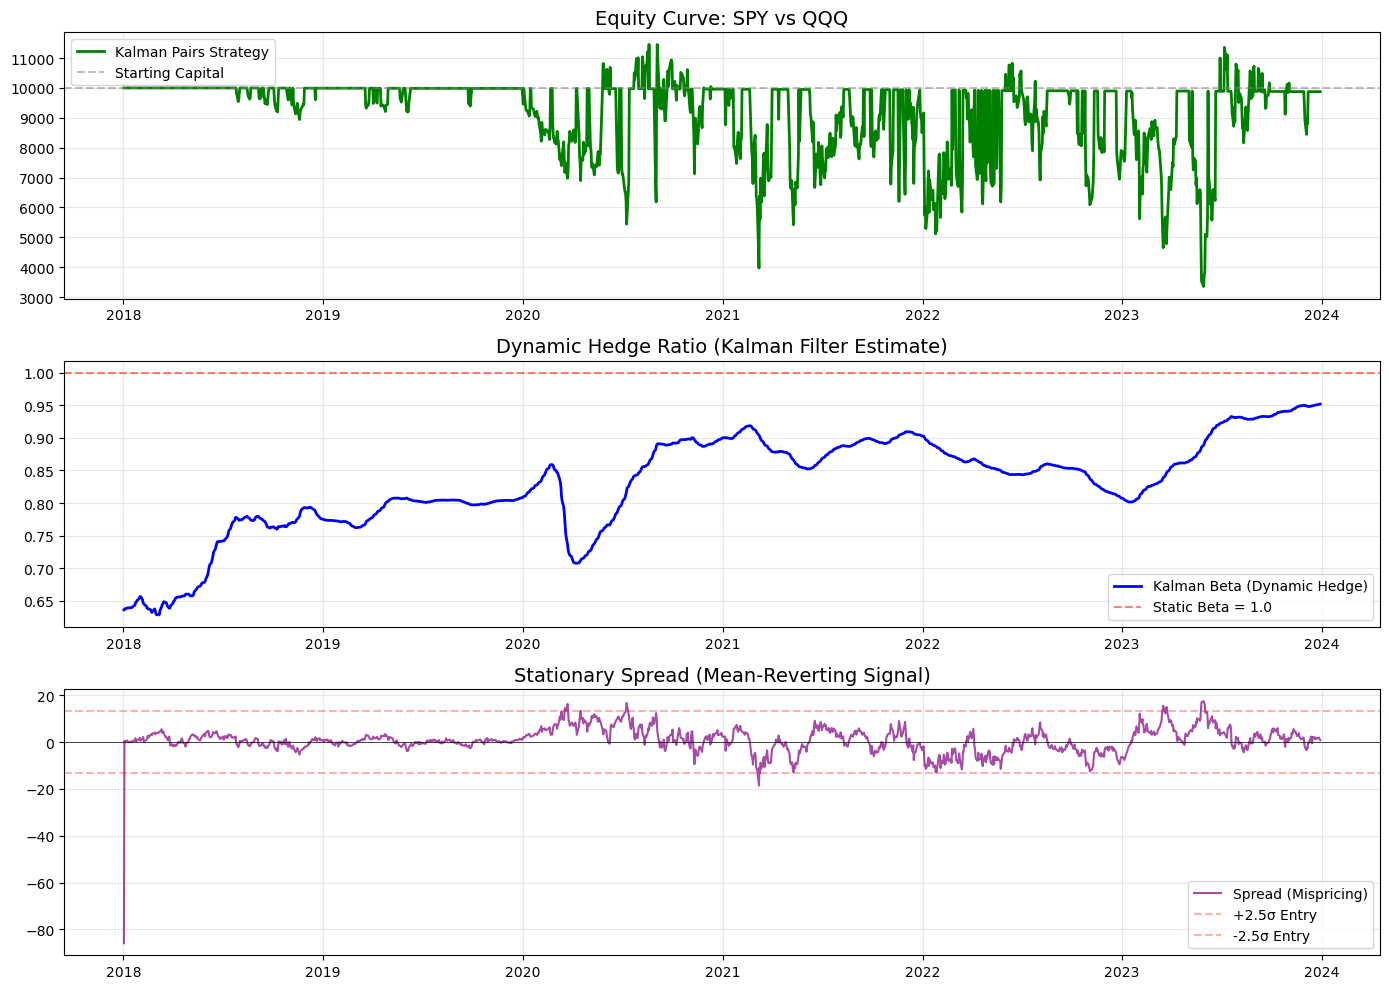

In [71]:
# -------------------- 5. PLOTTING (WITH REAL DATES) --------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Equity Curve
axes[0].plot(dates, equity, label='Kalman Pairs Strategy', color='green', linewidth=2)
axes[0].axhline(y=equity[0], color='gray', linestyle='--', alpha=0.5, label='Starting Capital')
axes[0].set_title(f'Equity Curve: {ticker_a} vs {ticker_b}', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Kalman Beta
axes[1].plot(dates, betas, label='Kalman Beta (Dynamic Hedge)', color='blue', linewidth=2)
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Static Beta = 1.0')
axes[1].set_title('Dynamic Hedge Ratio (Kalman Filter Estimate)', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Spread Residuals with Entry Thresholds
axes[2].plot(dates, residuals, label='Spread (Mispricing)', color='purple', alpha=0.7)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
std_resid = np.std(residuals)
axes[2].axhline(y=2.5 * std_resid, color='red', linestyle='--', alpha=0.3, label='+2.5σ Entry')
axes[2].axhline(y=-2.5 * std_resid, color='red', linestyle='--', alpha=0.3, label='-2.5σ Entry')
axes[2].set_title('Stationary Spread (Mean-Reverting Signal)', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()